<font face="Arial" size="4" color="black">
    
# Magic State Injection by Quantum Gate Teleportation

Author: Anastasiya Khromova (anastasiya.khromova17@gmail.com), 2026

The primary purpose of a gate teleportation circuit is to inject the non-Clifford resource from a pre-prepared magic state, such as an |H⟩-state, into a logical data qubit.

Consider a data qubit in an arbitrary state |ψ⟩. To perform a universal computation, we may need to apply a T-gate to this qubit (T |ψ⟩). However, many fault-tolerant codes cannot implement the T-gate directly because it is not a transversal Clifford operation. Instead, we use a gate teleportation circuit to consume a high-fidelity, pre-prepared Magic State. In this process, the Magic State is destroyed, and its non-Clifford kick is effectively transferred to the data qubit.

> The teleportation is the mechanism that utilizes the Magic State to perform the gate.

While standard quantum teleportation uses a Bell pair to transmit a qubit's state across locations, gate teleportation uses the Magic State as a resource to apply a specific logical gate. The typical circuit involves the data qubit and the Magic State (two wires), a CNOT gate, a measurement, and a conditional Clifford correction, such as an S-gate or a Pauli gate, depending on the measurement outcome (see Figure below). This mechanism allows for the execution of Level 3 operations while remaining within the constraints of a Clifford-only error correction framework.

The goal of this circuit is to apply a T-gate to the data qubit (wire q₀), but without actually applying a T-gate directly to it. Instead, we inject the power of the T-gate by consuming a special pre-prepared magic state on wire q₁. The QuTiP code below simulates the gate teleportation protocol to inject a T-gate into a data qubit using a Magic State. Here is the step-by-step breakdown of the implementation.

We import the necessary libraries as numpy for numeric calculations and qutip_qip specifically for defining quantum circuits and simulating their behavior, and we initialize a 2-qubit quantum circuit (N=2) with 2 classical bits (num_cbits=2) to store measurement results.

The system starts in a standard basis state. We create a tensor product of two basis(2, 0) vectors. Physically, this represents the starting state of the system as |00⟩ (both qubits in the |0⟩ state).

Data qubit q₀ is prepared in an arbitrary state using a RY rotation (θ=π/3). This represents the |ψ⟩ we want to process. A Magic State is prepared on the qubit q₁ using a Hadamard (H) gate followed by a T-gate. This creates a specific superposition state that is useful for fault-tolerant quantum computing.

In the injection protocol, the data qubit q₀ acts as the control, and the Magic State qubit q₁ acts as the target. This CNOT gate operation entangles the two qubits, linking the arbitrary phase of the data qubit with the magic resource of the ancilla. The CNOT acts as the interaction layer that allows the non-Clifford phase of the magic qubit to be mapped onto the logical data qubit during the subsequent measurement and correction steps.

The Magic State injection protocol works for any input state. The choice of theta only changes the specific quantum state you are testing, not the validity of the circuit itself. Then we do measurement and classical control:

> Measure qubit 1 (Magic Qubit), store result in classical bit 0
> 
> qc.add_measurement("M", targets=[1], classical_store=0)\
> 
> Apply S-gate to qubit 0 conditionally on classical bit 0
> 
> qc.add_gate("S", targets=[0], classical_controls=[0])

Qubit q₁ (the magic qubit) is measured. The result is written to the classical bit labeled 0. A gate (S-gate, phase flip) is applied to q₀. This gate only runs if the classical register 0  recorded a value of 1 (meaning the magic qubit measured was in the  |1⟩ state). This simulates measurement-based quantum logic (like  in a transversal logical gate).

Because quantum measurement is probabilistic, the simulation uses run_statistics to track both possible outcomes (0 or 1). It retrieves a list of the possible resulting states (final_states) and their respective probabilities (probabilities). If the measurement of q₁ is 1, an S-gate (Phase gate) must be applied to the data qubit q₀ to correct the state. If the measurement is 0, no correction is needed.

The code constructs the statistical mixture of the post-measurement outcomes. It iterates through every possible outcome state, weights it by its probability, and adds the pure state density matrix ρ=|ψ⟩⟨ψ| to a running total.

Since the magic qubit is consumed and measured out, we use the ptrace(rho, 0) to look only at the state of the data qubit q₀. The final density matrix target_dm, the reduced density matrix of the target qubit,  represents the state of the data qubit averaged over all measurement  outcomes. If the injection was successful, this matrix will match the  density matrix of the state T|RY(θ=π/3)⟩:

> Target Qubit (Wire 0) Density Matrix:
>
>  Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
> 
>   Qobj data =
> 
>   [[0.75      +0.j         0.30618622-0.30618622j]
> 
>   [0.30618622+0.30618622j 0.25      +0.j        ]]

The system retained the unbalanced nature of the theta = np. pi/3 rotation. The target qubit has a 75% probability of being measured in |0⟩and a 25% probability in |1⟩. If the computer had destroyed the quantum information, as a classical simulation might do for a collapsed state, the off-diagonal values would be zero. Because these values are non-zero (~0.306), the target qubit remains in a superposition that retains memory traces of the magic qubit.

</font>

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
Magic State Shape: (4, 1)
Magic State: Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.61237244+0.j       ]
 [0.4330127 +0.4330127j]
 [0.25      +0.25j     ]
 [0.35355339+0.j       ]]

Target Qubit (Wire 0) Density Matrix:
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.75       0.30618622]
 [0.30618622 0.25      ]]
Simulation Results:
Outcome 0 (Prob 0.5000):
Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.8660254 +0.j        ]
 [0.        +0.j        ]
 [0.35355339+0.35355339j]
 [0.        +0.j        ]]
Outcome 1 (Prob 0.5000):
Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.61237244+0.61237244j]
 [0.        +0.j        ]
 [0.        +0.5j       ]]
Full 2-Qubit Density Ma

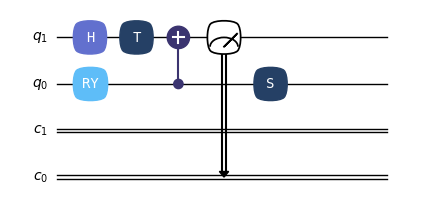

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import * #Qutip is a Python library for simulating quantum systems.
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import *  # Import gate operations
from qutip import tensor
from qutip.measurement import measure, measurement_statistics

qc = QubitCircuit(N=2, num_cbits=2)

# Initial state: all qubits in |0⟩ state
initial_state = tensor([basis(2, 0) for _ in range(qc.N)])
print(initial_state)

theta = np.pi / 3
# Prepare the arbitrary state on Qubit 0
qc.add_gate("RY", targets=[0], arg_value=theta)
# Prepare Magic State (H then T) on Qubit 1
qc.add_gate("H", targets=[1])
qc.add_gate("T", targets=[1])
# Apply CNOT for injection. Note: In injection, Control is the Data (0), Target is the Magic (1)
qc.add_gate("CNOT", targets=[1], controls=[0])

# Simulate the circuit
result = qc.run(state=initial_state)
# Get the final state
Magic_State = result
print("Magic State Shape:", Magic_State.shape)
print("Magic State:", Magic_State)
rho=ket2dm(Magic_State)
rho_partial = ptrace(rho, 0)
print("\nTarget Qubit (Wire 0) Density Matrix:\n", rho_partial)


# Add Measurement on Qubit 1 (Magic Qubit) and store result in classical register 0
qc.add_measurement("M", targets=[1], classical_store=0)

# Add the Classically Controlled S-Gate. If classical register 0 is 1, apply S to qubit 0
qc.add_gate("S", targets=[0], classical_controls=[0])

# Since this circuit has measurements, we look at the statistics or final states. We use run_statistics to handle the branching paths
result = qc.run_statistics(state=initial_state)
# Get the final states and their probabilities
final_states = result.get_final_states()
probabilities = result.get_probabilities()

print("Simulation Results:")
for i, p in enumerate(probabilities):
    print(f"Outcome {i} (Prob {p:.4f}):")
    print(final_states[i])

total_density_matrix = 0 * ket2dm(final_states[0])

for state, prob in zip(final_states, probabilities):
    total_density_matrix += prob * ket2dm(state)

print("Full 2-Qubit Density Matrix:\n", total_density_matrix)

#Trace out the magic qubit (wire 1) to see the target qubit (wire 0)
target_dm = ptrace(total_density_matrix, 0)
print("\nTarget Qubit (Wire 0) Density Matrix:\n", target_dm)

fig, ax = plt.subplots(figsize=(4, 2))  # Adjust the figure size as needed
qc.draw("matplotlib", ax=ax)
#fig.savefig('magic_state_injection_circuit.png', dpi=300, bbox_inches='tight')

<font face="Arial" size="4" color="black">

#  Magic State Distillation

Manufacturing high-quality Magic States is difficult. Noisy, i.e., |H⟩-states, would introduce errors into the computation. Magic state distillation (MSD) solves this by purifying noisy Magic States using quantum error correction [12].

There are several steps in the MSD protocol:

1. Preparation/Injection. Take many noisy Magic States with error rate ε.
2. Encoding. Use a quantum error-correcting code (inner) to encode these input states. This is the core of the process. Encoding stores the noisy input states within the structure of a quantum error-correcting code (usually a code of distance 3, like the 5-qubit code or 9-qubit Shor code).
3. Transversal operation. Apply Clifford gates (which can be done fault-tolerantly) across the code. The Clifford gates do not degrade the state further; they only serve to entangle the states, allowing for the checking of errors.
4. Perform a syndrome measurement. Measure the stabilizers of the code to check for errors.
5. Do the post-selection. If the measurement indicates no errors (trivial syndrome), the state is kept; if errors are detected, the state is discarded. If the syndrome indicates no errors, the remaining output state has an error rate ∼ ε³ (for distance-3 codes) or better. A distance-d code can detect and discard all states where the error affects fewer than d qubits. If the input error rate is ε, the probability that a specific block passes through this filter (because it has high-weight errors) or fails (because it has low-weight errors) relies on the combinatorial probability of errors occurring on d distinct qubits, which scales roughly with εᵈ.
6. Repeat the cascade multiple times to achieve arbitrarily high fidelity.

> MSD protocols are typically based on specific quantum error-correcting codes that possess certain symmetries. [[5,1,3]] code is one of the most fundamental MSD protocols, often used for distilling states. It takes five noisy Magic States as input and outputs one of higher fidelity if the initial error is below a certain threshold.


A decoder for the 5-qubit perfect quantum code, the [[5,1,3]] stabilizer code (see the Figure below), is the smallest possible quantum error-correcting code that can fix any single-qubit error (bit flip, phase flip, or both). It encodes 1 logical qubit into 5 physical qubits. The last number 3 is a code distance - the minimum number of physical errors needed to turn one logical state into another. Distance 3 means it can detect 2 errors or correct 1 error of any type. No smaller code can protect against all single-qubit errors (you need at least 5). It uses the minimum number of physical qubits necessary for the job.

In a 5-qubit code, the data is hidden in a 32-dimensional space (2⁵). The decoder uses parity checks (the CNOTs and CZs) to see if the state has drifted away from the allowed logical space. CNOTs usually detect Bit-flips (X errors), and CZs usually detect Phase-flips (Z errors).

The code below demonstrates a Robust Quantum State Preparation workflow. It specifically simulates how a 5-qubit error-correcting code handles noise during the creation of T-states (Magic States).

The variable b is calculated using arccos(1/√3), which is the specific angle needed to place a qubit on the Bloch sphere such that a subsequent Phase gate creates a T-state. This state is a fundamental building block for universal quantum computing. Instead of a perfect gate, we introduce Gaussian Noise (n1, n2). You can also use random.uniform(-r,r,2), where the parameter r acts as the noise floor: as r increases, the fidelity of the T-state drops. This simulates over-rotation or under-rotation errors caused by hardware imperfections.

The 5-Qubit Decoder (error_correction_decoder) is the core of the script. It uses a series of CNOT and CZ gates to perform parity checks across the 5 qubits. The gates map the errors (flips or phase shifts) from the data qubits onto the ancilla qubits (syndrome extraction). The Z gates at the end suggest the circuit is designed to catch and fix specific phase errors before the final measurement (Pauli corrections). The final loop for w in [w1, w2, w3, w4]: qc.add_gate("H", targets=[w]) is crucial. The Hadamard (H) gates rotate the ancilla qubits into the X-basis before measurement. This allows the computer to read the error signature (the syndrome) clearly. In a real experiment, you would measure these 4 qubits to decide exactly which correction to apply to the 0th qubit. In this code, w0 (q₀) acts as the logical qubit. The other four qubits (w1 through w4) are the ancilla qubits  used to guard the first one. The decoder is essentially squeezing  the noise out of the 5-qubit system and dumping it into the ancillas,  leaving Wire 0 (q₀) as clean as possible.

Simulation Logic (__name__ == "__main__"), we are applying the noisy generation to all 5 qubits simultaneously in a loop. By running the decoder after the noisy generation, we are testing if the 5-qubit code can clean up the noise and recover a high-quality state.

The [[5,1,3]] code is defined by four stabilizer generators, which are tensor products of Pauli operators acting on the five qubits:

g₁ = X Z Z X I

g₂ = I X Z Z X

g₃ = X I X Z Z

g₄ = Z X I X Z

In our circuit, the error_correction_decoder function implements the [[5,1,3]] stabilizer code, which uses four generators, g₁ to g₄, to detect errors. In this implementation, the CNOT and CZ gates perform these parity checks in a compressed way. By mapping these Pauli strings (like XZZXI) onto the ancilla wires, the decoder identifies if a bit-flip or phase-flip occurred and applies the necessary Pauli corrections to restore the logical state.

> For the [[5, 1, 3]] code, the threshold fidelity for depolarizing errors is 83%. - Sergey Bravyi and Alexei Kitaev. Universal quantum computation with ideal Clifford gates and noisy ancillas, Physical Review A, 71(2):022316, 2005, [13]
>
> If the input fidelity exceeds the so-called distillation threshold, the fidelity of the output state is improved compared to the input. 
-Experimental demonstration of logical Magic State distillation, Pedro Sales Rodriguez, https://www.researchgate.net/publication/387264728_Experimental_Demonstration_of_Logical_Magic_State_Distillation, [14]
>

</font>


--- Faulty Circuit + Error Correction ---


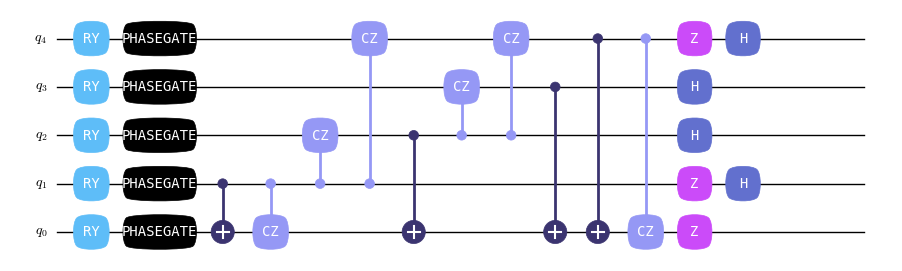

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import *  # Import gate operations
from qutip import tensor
from qutip.measurement import measure, measurement_statistics
import matplotlib.pyplot as plt



b = 0.5 * np.arccos(1 / np.sqrt(3))

def generate_pure_T0(qc, wire):
    """Standard T-state: RY(2b) then Phase(pi/4)"""
    qc.add_gate("RY", targets=wire, arg_value=2 * b)
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4)

def faulty_generate_T0(qc, wire, key, r):
    """Noisy T-state generation"""
    rng = np.random.default_rng(key)
    n1, n2 = rng.normal(0, r), rng.normal(0, r)
    qc.add_gate("RY", targets=wire, arg_value=2 * (b + n1))
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4 + n2)

def error_correction_decoder(qc, wires):
    """The 5-qubit code decoder from the PennyLane example."""
    w0, w1, w2, w3, w4 = wires
    # Parity checks
    qc.add_gate("CNOT", targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w2], controls=[w1])
    qc.add_gate("CZ",   targets=[w4], controls=[w1])
    qc.add_gate("CNOT", targets=[w0], controls=[w2])
    qc.add_gate("CZ",   targets=[w3], controls=[w2])
    qc.add_gate("CZ",   targets=[w4], controls=[w2])
    qc.add_gate("CNOT", targets=[w0], controls=[w3])
    qc.add_gate("CNOT", targets=[w0], controls=[w4])
    qc.add_gate("CZ",   targets=[w0], controls=[w4])
    # Pauli Corrections
    qc.add_gate("Z", targets=[w0])
    qc.add_gate("Z", targets=[w1])
    qc.add_gate("Z", targets=[w4])
    # Basis change for measurement
    for w in [w1, w2, w3, w4]:
        qc.add_gate("H", targets=[w])

if __name__ == "__main__":
    #qc = QubitCircuit(N=5, num_cbits=5)
    qc = QubitCircuit(N=5)
    initial_state = tensor([basis(2, 0) for _ in range(qc.N)])
    wires =[0,1,2,3,4]
    
    seed = np.random.randint(0, 100000)
    for i in range(5):
            faulty_generate_T0(qc, i, seed + i, r = 0.1)
    #faulty_generate_T0(qc, 0, seed, r=0.1)
    
    #faulty_result = qc.run(state=initial_state)
    #print("\nFaulty T State Density Matrix (approx):")
    #print(faulty_result)
    error_correction_decoder(qc, wires)
    faulty_result = qc.run(state=initial_state)

    print("\n--- Faulty Circuit + Error Correction ---")
    fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the figure size as needed
    qc.draw("matplotlib", ax=ax)
    #fig.savefig('error_correction_decoder_final.png', dpi=300, bbox_inches='tight')
    #qc.draw()

    

<font face="Arial" size="4" color="black">

The function state_distillation, is a post-selection simulation. It attempts to clean a noisy quantum state by running the 5-qubit error correction code and only keeping the results where no errors were detected. The line U_rec = sigmay() * snot()  creates a specific mathematical transformation (Hadamard then Y-gate).  This is necessary because the 5-qubit code often leaves the logical  qubit in a rotated basis. This operator aligns the final state so it can be compared directly to the perfect target state (the exact_dm). The iterative loop (max_attempts) tries up to 100 times to find a clean run since quantum error correction is probabilistic. It generates 5 noisy T-states, passes them through the error_correction_decoder. Syndrome Projection is the most critical part of the function. proj_all_zero creates a mathematical filter (a projector) that looks at the four ancilla qubits (Wires 1–4). It throws away any simulation where the ancilla qubits are not in the |0000⟩state. In quantum computing, if the ancillas are all zero after decoding, it means no uncorrectable errors were detected, and this is called post-selection. When you filter a state, the resulting vector shrinks. You must re-normalize it (divide by the norm) to make it a valid quantum state again, with projected_state.norm(). The ptrace(0) isolates the 0th qubit (the logical qubit) from the rest of the 5-qubit system. If the filter succeeds (norm > 1e⁻⁴), it applies the recovery rotation and returns the clean density matrix of the distilled qubit.

The if __name__ == "__main__": block is the experiment runner.  It measures the effectiveness of the error correction by comparing a  noisy state to a purified/distilled state across a range of noise levels. First, it creates a perfect T-state using generate_pure_T0. This is the reference point (Fidelity = 1.0) against which all noisy results will be compared.

The code loops through 20 different noise levels (r),  from 0.0 (perfect) to 1.0 (extremely noisy). At each level, it repeats  the simulation 200 times to get a statistically reliable average.
For every noise level, it calculates two different fidelities:

- Pre-Distillation (pres): How good is a single qubit if we just apply the noisy gate and do nothing else?
- Post-Distillation (posts): How good is the qubit after it has been processed by the 5-qubit code and "filtered" by the state_distillation function.

In quantum error correction, there is a specific noise level where the correction actually makes things worse (because the gates used to fix the error introduce more noise than they remove). The code looks for the point where the Post-Distillation line crosses below the Pre-Distillation line. It uses linear interpolation to find the exact value of r where the two lines meet. This is the error threshold.

</font>

Running for noise r=0.00...
Running for noise r=0.05...
Running for noise r=0.11...
Running for noise r=0.16...
Running for noise r=0.21...
Running for noise r=0.26...
Running for noise r=0.32...
Running for noise r=0.37...
Running for noise r=0.42...
Running for noise r=0.47...
Running for noise r=0.53...
Running for noise r=0.58...
Running for noise r=0.63...
Running for noise r=0.68...
Running for noise r=0.74...
Running for noise r=0.79...
Running for noise r=0.84...
Running for noise r=0.89...
Running for noise r=0.95...
Running for noise r=1.00...
Estimated Threshold r: 0.3908
Threshold Fidelity F: 0.8465
File saved correctly.


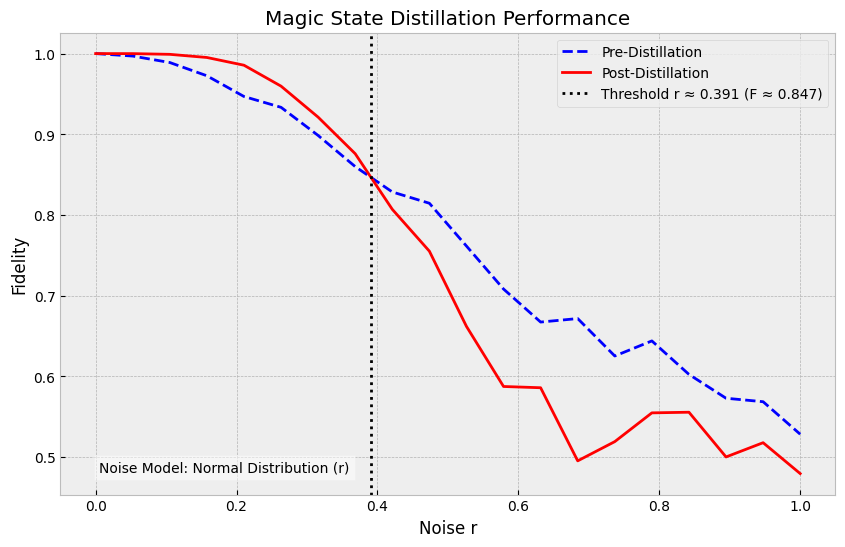

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import *  # Import gate operations
from qutip import tensor
from qutip.measurement import measure, measurement_statistics
import matplotlib.pyplot as plt


# 1. PARAMETERS (Matching PennyLane T-state)
b = 0.5 * np.arccos(1 / np.sqrt(3))

def generate_pure_T0(qc, wire):
    """Standard T-state: RY(2b) then Phase(pi/4)"""
    qc.add_gate("RY", targets=wire, arg_value=2 * b)
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4)

def faulty_generate_T0(qc, wire, key, r):
    """Noisy T-state generation"""
    rng = np.random.default_rng(key)
    n1, n2 = rng.normal(0, r), rng.normal(0, r)
    qc.add_gate("RY", targets=wire, arg_value=2 * (b + n1))
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4 + n2)

def error_correction_decoder(qc, wires):
    """The 5-qubit code decoder from the PennyLane example."""
    w0, w1, w2, w3, w4 = wires
    # Parity checks
    qc.add_gate("CNOT", targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w2], controls=[w1])
    qc.add_gate("CZ",   targets=[w4], controls=[w1])
    qc.add_gate("CNOT", targets=[w0], controls=[w2])
    qc.add_gate("CZ",   targets=[w3], controls=[w2])
    qc.add_gate("CZ",   targets=[w4], controls=[w2])
    qc.add_gate("CNOT", targets=[w0], controls=[w3])
    qc.add_gate("CNOT", targets=[w0], controls=[w4])
    qc.add_gate("CZ",   targets=[w0], controls=[w4])
    # Pauli Corrections
    qc.add_gate("Z", targets=[w0])
    qc.add_gate("Z", targets=[w1])
    qc.add_gate("Z", targets=[w4])
    # Basis change for measurement
    for w in [w1, w2, w3, w4]:
        qc.add_gate("H", targets=[w])

def state_distillation(wires, targets, seed_value, r):
    max_attempts = 100
    # Recovery alignment: H then Y. This rotates the output of the 5-qubit code back to the computational basis 
    #where your exact_dm is defined.
    U_rec = sigmay() * snot() 
    
    for _ in range(max_attempts):
        qc = QubitCircuit(N=5)
        for i in range(5):
            faulty_generate_T0(qc, i, seed_value + i, r)
        error_correction_decoder(qc, wires)
        
        # Run state evolution
        initial_state = tensor([basis(2,0)]*5)
        result_state = qc.run(state=initial_state)
        
        # SYNDROME PROJECTION: Quits must be |0000> on targets
        # We manually project to simulate "keeping only 0000 results"
        P0 = basis(2,0) * basis(2,0).dag()
        #This mathematically filters the wave function to keep only the part where the syndrome is 0000.
        #It’s the equivalent of "perfect post-selection."
        proj_all_zero = tensor(qeye(2), P0, P0, P0, P0)
        
        projected_state = proj_all_zero * result_state
        #When you project a state in QuTiP (e.g., projected_state = P * psi), the resulting vector is no longer normalized (its length is less than 1).
        #If you calculate fidelity using a non-normalized state, the result will be mathematically lower than it actually is
        norm = projected_state.norm()
        
        if norm > 1e-4: # Success branch
            rho_q0 = (projected_state / norm).ptrace(0)
            # Apply recovery and return 1-qubit DM
            return (U_rec * rho_q0 * U_rec.dag()).unit()
            
    return None

if __name__ == "__main__":
    # Reference target state
    qc_ref = QubitCircuit(1)
    generate_pure_T0(qc_ref, 0)
    exact_dm = (qc_ref.run(state=basis(2,0))).ptrace(0)

    perturbations = np.linspace(0.0, 1.0, 20)
    repeats = 200
    
    pres, posts = [], []

    for r in perturbations:
        print(f"Running for noise r={r:.2f}...")
        pre_f, post_f = [], []
        for k in range(repeats): # Repeats
            seed = np.random.randint(0, 100000)
            # Pre-distillation fidelity
            qc_n = QubitCircuit(1)
            faulty_generate_T0(qc_n, 0, seed, r)
            rho_noisy = qc_n.run(state=basis(2,0)).ptrace(0)
            pre_f.append(fidelity(rho_noisy, exact_dm)**2)
            
            # Post-distillation
            rho_dist = state_distillation([0,1,2,3,4], [1,2,3,4], seed, r)
            if rho_dist:
                post_f.append(fidelity(rho_dist, exact_dm)**2)

        pres.append(np.mean(pre_f))
        posts.append(np.mean(post_f) if post_f else 0)

    for i in range(len(perturbations) - 1):
        diff_start = posts[i] - pres[i]
        diff_end = posts[i+1] - pres[i+1]
    
    # If the sign changes, the crossing is between these two points
        if diff_start > 0 and diff_end < 0:
            # Linear interpolation to find the exact r
            r_low = perturbations[i]
            r_high = perturbations[i+1]
            threshold_r = r_low + (r_high - r_low) * (diff_start / (diff_start - diff_end))
            print(f"Estimated Threshold r: {threshold_r:.4f}")
            break

    #fig = plt.gcf()
    fig, ax = plt.subplots(figsize=(10, 6)) 
    plt.style.use("bmh")
    #plt.figure(figsize=(10, 6))
    plt.plot(perturbations, pres, 'b--', label="Pre-Distillation")
    plt.plot(perturbations, posts, 'r-', label="Post-Distillation")

    #if threshold_r is not None:
    #    plt.axvline(x=threshold_r, color='black', linestyle=':', 
    #                label=f'Threshold r ≈ {threshold_r:.3f}')

    if threshold_r is not None:
        # Find the nearest index for interpolation
        i = np.searchsorted(perturbations, threshold_r) - 1
        r_low, r_high = perturbations[i], perturbations[i+1]
        f_low, f_high = pres[i], pres[i+1]

        # Interpolate the fidelity corresponding to threshold_r
        # This calculates the Y-value (Fidelity) where the two lines cross
        threshold_fidelity = f_low + (threshold_r - r_low) * (f_high - f_low) / (r_high - r_low)
        print(f"Threshold Fidelity F: {threshold_fidelity:.4f}")

        # Draw the vertical line and add both r and F to the legend
        plt.axvline(x=threshold_r, color='black', linestyle=':', 
                    label=f'Threshold r ≈ {threshold_r:.3f} (F ≈ {threshold_fidelity:.3f})')

    plt.text(0.05, 0.05, "Noise Model: Normal Distribution (r)", 
             transform=plt.gca().transAxes, fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.5))
        
    plt.title("Magic State Distillation Performance")
    plt.xlabel("Noise r")
    plt.ylabel("Fidelity")
    plt.legend()
    
    fig.savefig('magic_state_distillation_normal_distr_200repeats.png', dpi=300, bbox_inches='tight')
    print("File saved correctly.")

    plt.show()
    

<font face="Arial" size="4" color="black">

In a normal (Gaussian) distribution rng.normal(0, r), the noise is concentrated near zero, but it has tails. This means we occasionally get very large errors (outliers) even at lower r values. Quantum error correction (the 5-qubit code) is very good at fixing small, consistent errors, but it struggles with these sudden, large deviations. Because the Normal model produces these extreme spikes more often, the code breaks sooner (at a lower r).

In the uniform distribution random.uniform(-r, r, 2) every error is equally likely between -r and +r, but it never exceeds r. The noise is predictable in its range. Since there are no extreme outliers (no tails), the 5-qubit code can handle a much higher value of r before the cumulative noise becomes too much for the stabilizers to correct. The normal model is more realistic for hardware (where random spikes happen), but it is much harder on the error decoder. The uniform model allows us to push the noise parameter r much further because the errors are more constrained.

In quantum mechanics, the average fidelity for a qubit subject to small random perturbations is often approximated as F ≈ 1−3/4 ε, where ε is the error rate. By using this formula, we are converting the geometric noise r into a physical fidelity value that can be compared to other quantum benchmarks. In the get_fidelity function, we use 1.0 - 0.75 * variance. If r represents the standard deviation of the rotation angle in radians, this formula is a very good first-order approximation. If the noise is very large (e.g., r > 1.0 ), the linear approximation breaks down, but for the threshold values ( 0.39 and 0.63), it remains a valid scientific estimate. The Uniform model actually requires a slightly higher initial fidelity to cross the threshold, confirming it is the easier noise to correct.

</font>

Running for noise r=0.00...
Running for noise r=0.05...
Running for noise r=0.11...
Running for noise r=0.16...
Running for noise r=0.21...
Running for noise r=0.26...
Running for noise r=0.32...
Running for noise r=0.37...
Running for noise r=0.42...
Running for noise r=0.47...
Running for noise r=0.53...
Running for noise r=0.58...
Running for noise r=0.63...
Running for noise r=0.68...
Running for noise r=0.74...
Running for noise r=0.79...
Running for noise r=0.84...
Running for noise r=0.89...
Running for noise r=0.95...
Running for noise r=1.00...
Estimated Threshold r: 0.6525
Threshold Fidelity F: 0.8600
File saved correctly.


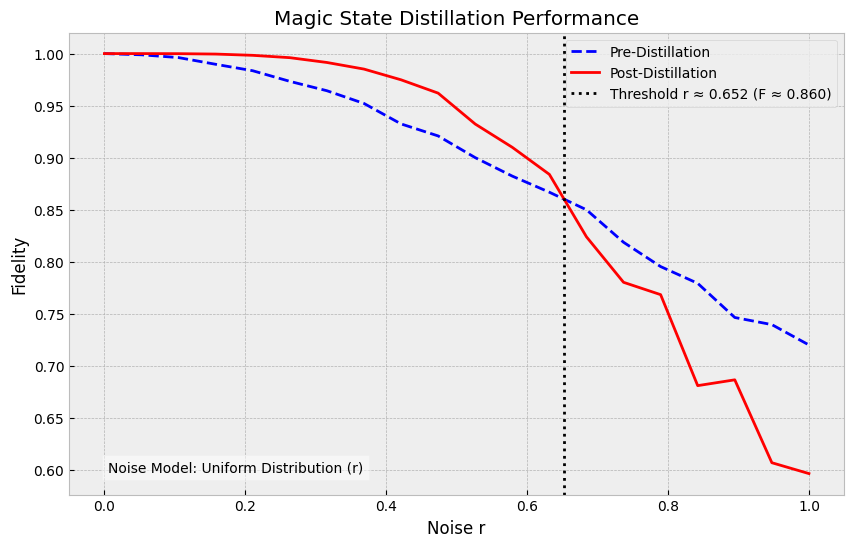

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import *  # Import gate operations
from qutip import tensor
from qutip.measurement import measure, measurement_statistics
import matplotlib.pyplot as plt


# 1. PARAMETERS (Matching PennyLane T-state)
b = 0.5 * np.arccos(1 / np.sqrt(3))

def generate_pure_T0(qc, wire):
    """Standard T-state: RY(2b) then Phase(pi/4)"""
    qc.add_gate("RY", targets=wire, arg_value=2 * b)
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4)

def faulty_generate_T0(qc, wire, key, r):
    """Noisy T-state generation"""
    rng = np.random.default_rng(key)
    #n1, n2 = rng.normal(0, r), rng.normal(0, r)
    n1, n2 = np.random.uniform(-r, r, 2)
    qc.add_gate("RY", targets=wire, arg_value=2 * (b + n1))
    qc.add_gate("PHASEGATE", targets=wire, arg_value=np.pi/4 + n2)

def error_correction_decoder(qc, wires):
    """The 5-qubit code decoder from the PennyLane example."""
    w0, w1, w2, w3, w4 = wires
    # Parity checks
    qc.add_gate("CNOT", targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w0], controls=[w1])
    qc.add_gate("CZ",   targets=[w2], controls=[w1])
    qc.add_gate("CZ",   targets=[w4], controls=[w1])
    qc.add_gate("CNOT", targets=[w0], controls=[w2])
    qc.add_gate("CZ",   targets=[w3], controls=[w2])
    qc.add_gate("CZ",   targets=[w4], controls=[w2])
    qc.add_gate("CNOT", targets=[w0], controls=[w3])
    qc.add_gate("CNOT", targets=[w0], controls=[w4])
    qc.add_gate("CZ",   targets=[w0], controls=[w4])
    # Pauli Corrections
    qc.add_gate("Z", targets=[w0])
    qc.add_gate("Z", targets=[w1])
    qc.add_gate("Z", targets=[w4])
    # Basis change for measurement
    for w in [w1, w2, w3, w4]:
        qc.add_gate("H", targets=[w])

def state_distillation(wires, targets, seed_value, r):
    max_attempts = 100
    # Recovery alignment for PennyLane: H then Y. This rotates the output of the 5-qubit code back to the computational basis 
    #where your exact_dm is defined.
    U_rec = sigmay() * snot() 
    
    for _ in range(max_attempts):
        qc = QubitCircuit(N=5)
        for i in range(5):
            faulty_generate_T0(qc, i, seed_value + i, r)
        error_correction_decoder(qc, wires)
        
        # Run state evolution
        initial_state = tensor([basis(2,0)]*5)
        result_state = qc.run(state=initial_state)
        
        # SYNDROME PROJECTION: Quits must be |0000> on targets
        # We manually project to simulate "keeping only 0000 results"
        P0 = basis(2,0) * basis(2,0).dag()
        #This mathematically filters the wave function to keep only the part where the syndrome is 0000.
        #It’s the equivalent of "perfect post-selection."
        proj_all_zero = tensor(qeye(2), P0, P0, P0, P0)
        
        projected_state = proj_all_zero * result_state
        #When you project a state in QuTiP (e.g., projected_state = P * psi), the resulting vector is no longer normalized (its length is less than 1).
        #If you calculate fidelity using a non-normalized state, the result will be mathematically lower than it actually is
        norm = projected_state.norm()
        
        if norm > 1e-4: # Success branch
            rho_q0 = (projected_state / norm).ptrace(0)
            # Apply recovery and return 1-qubit DM
            return (U_rec * rho_q0 * U_rec.dag()).unit()
            
    return None

if __name__ == "__main__":
    # Reference target state
    qc_ref = QubitCircuit(1)
    generate_pure_T0(qc_ref, 0)
    exact_dm = (qc_ref.run(state=basis(2,0))).ptrace(0)

    perturbations = np.linspace(0.0, 1.0, 20)
    repeats = 200
    
    pres, posts = [], []

    for r in perturbations:
        print(f"Running for noise r={r:.2f}...")
        pre_f, post_f = [], []
        for k in range(repeats): # Repeats
            seed = np.random.randint(0, 100000)
            # Pre-distillation fidelity
            qc_n = QubitCircuit(1)
            faulty_generate_T0(qc_n, 0, seed, r)
            rho_noisy = qc_n.run(state=basis(2,0)).ptrace(0)
            pre_f.append(fidelity(rho_noisy, exact_dm)**2)
            
            # Post-distillation
            rho_dist = state_distillation([0,1,2,3,4], [1,2,3,4], seed, r)
            if rho_dist:
                post_f.append(fidelity(rho_dist, exact_dm)**2)

        pres.append(np.mean(pre_f))
        posts.append(np.mean(post_f) if post_f else 0)

    for i in range(len(perturbations) - 1):
        diff_start = posts[i] - pres[i]
        diff_end = posts[i+1] - pres[i+1]
    
    # If the sign changes, the crossing is between these two points
        if diff_start > 0 and diff_end < 0:
            # Linear interpolation to find the exact r
            r_low = perturbations[i]
            r_high = perturbations[i+1]
            threshold_r = r_low + (r_high - r_low) * (diff_start / (diff_start - diff_end))
            print(f"Estimated Threshold r: {threshold_r:.4f}")
            break

    #fig = plt.gcf()
    fig, ax = plt.subplots(figsize=(10, 6)) 
    plt.style.use("bmh")
    #plt.figure(figsize=(10, 6))
    plt.plot(perturbations, pres, 'b--', label="Pre-Distillation")
    plt.plot(perturbations, posts, 'r-', label="Post-Distillation")

    
    
    if threshold_r is not None:
        # Find the nearest index for interpolation
        i = np.searchsorted(perturbations, threshold_r) - 1
        r_low, r_high = perturbations[i], perturbations[i+1]
        f_low, f_high = pres[i], pres[i+1]

        # Interpolate the fidelity corresponding to threshold_r
        # This calculates the Y-value (Fidelity) where the two lines cross
        threshold_fidelity = f_low + (threshold_r - r_low) * (f_high - f_low) / (r_high - r_low)
        print(f"Threshold Fidelity F: {threshold_fidelity:.4f}")

        # Draw the vertical line and add both r and F to the legend
        plt.axvline(x=threshold_r, color='black', linestyle=':', 
                    label=f'Threshold r ≈ {threshold_r:.3f} (F ≈ {threshold_fidelity:.3f})')

       
        #plt.axvline(x=threshold_r, color='black', linestyle=':', 
        #            label=f'Threshold r ≈ {threshold_r:.3f}')

    

    

    plt.text(0.05, 0.05, "Noise Model: Uniform Distribution (r)", 
             transform=plt.gca().transAxes, fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.5))
        
    plt.title("Magic State Distillation Performance")
    plt.xlabel("Noise r")
    plt.ylabel("Fidelity")
    plt.legend()
    
    #fig.savefig('magic_state_distillation_uniform_distr_200repeats_final.png', dpi=300, bbox_inches='tight')
    print("File saved correctly.")

    plt.show()
    

<font face="Arial" size="4" color="black">

Now we do a consistency check plot for Magic State distillation, where we compare our simulated threshold fidelities against the known theoretical limit.

The markers represent the points in the Figure above where Fᵢₙ = Fₒᵤₜ), showing the transition into the Distillation Success Zone. Both markers fall in the same regime (~0.9), well above the theoretical limit of 0.85, confirming the threshold is primarily determined by the code's stabilizer structure rather than the specific noise distribution. The shift from the theoretical limit 0.85 to our simulated 0.89 reflects the additional overhead required to correct systematic unitary perturbations in the T-state preparation.

</font>

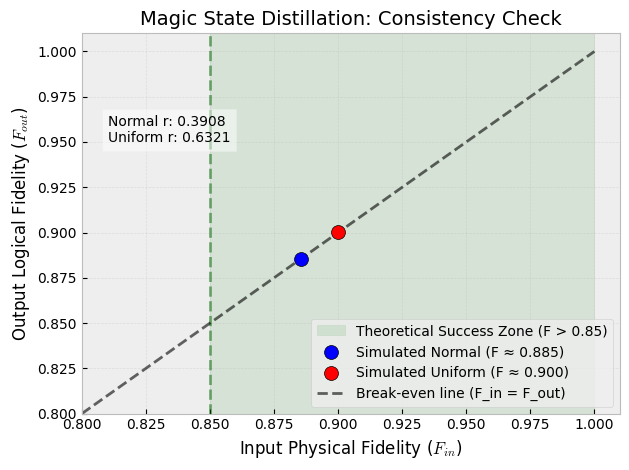

Fidelity Threshold (Normal): 0.8855
Fidelity Threshold (Uniform): 0.9001


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip_qip.circuit import QubitCircuit

# Parameter T-state
b = 0.5 * np.arccos(1 / np.sqrt(3))

def get_fidelity(r, mode="normal"):
    """Calculate the average input fidelity based on the noise r."""
    if mode == "normal":
        variance = r**2
    else: # uniform
        variance = (r**2) / 3.0
    # Physical approximation for the squared error on two axes
    return 1.0 - 0.75 * variance

#Data obtained from my simulations
r_normal = 0.3908
r_uniform = 0.6321

# Calculating Threshold Fidelity
f_threshold_normal = get_fidelity(r_normal, "normal")
f_threshold_uniform = get_fidelity(r_uniform, "uniform")

# --- PLOTTING ---
#plt.figure(figsize=(10, 6))
#plt.style.use("bmh")

# Success Area (Above Threshold)
#plt.axvspan(0.90, 1.0, color='green', alpha=0.1, label="Distillation Success Zone")

# Markers for the two Thresholds
#plt.scatter([f_threshold_normal], [f_threshold_normal], color='blue', s=100, 
#            label=f'Normal Threshold (F ≈ {f_threshold_normal:.3f})', zorder=5)
#plt.scatter([f_threshold_uniform], [f_threshold_uniform], color='red', s=100, 
#            label=f'Uniform Threshold (F ≈ {f_threshold_uniform:.3f})', zorder=5)

# Theoretical threshold for the [[5,1,3]] code under depolarizing noise
f_theoretical = 0.85 

# Success Area: Starts from the theoretical limit
plt.axvspan(f_theoretical, 1.0, color='green', alpha=0.1, label=f"Theoretical Success Zone (F > {f_theoretical})")

# Markers for your specific simulations
plt.scatter([f_threshold_normal], [f_threshold_normal], color='blue', s=100, 
            edgecolor='black', label=f'Simulated Normal (F ≈ {f_threshold_normal:.3f})', zorder=5)
plt.scatter([f_threshold_uniform], [f_threshold_uniform], color='red', s=100, 
            edgecolor='black', label=f'Simulated Uniform (F ≈ {f_threshold_uniform:.3f})', zorder=5)

# Add a vertical line for the Theoretical Limit
plt.axvline(x=f_theoretical, color='darkgreen', linestyle='--', alpha=0.5)


# Reference line F_in = F_out
x = np.linspace(0.8, 1.0, 50)
plt.plot(x, x, 'k--', alpha=0.6, label="Break-even line (F_in = F_out)")

# Scientific Notes
plt.text(0.81, 0.95, f"Normal r: {r_normal}\nUniform r: {r_uniform}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.title("Magic State Distillation: Consistency Check", fontsize=14)
plt.xlabel("Input Physical Fidelity ($F_{in}$)", fontsize=12)
plt.ylabel("Output Logical Fidelity ($F_{out}$)", fontsize=12)
plt.xlim(0.80, 1.01)
plt.ylim(0.80, 1.01)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('msd_consistency_check_final.png', dpi=300)
plt.show()

print(f"Fidelity Threshold (Normal): {f_threshold_normal:.4f}")
print(f"Fidelity Threshold (Uniform): {f_threshold_uniform:.4f}")

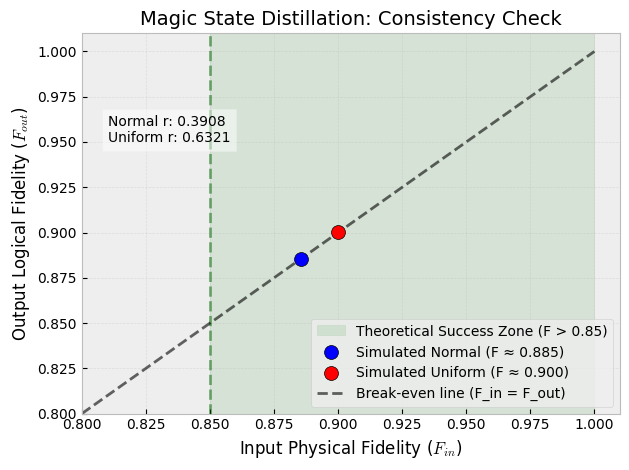

Fidelity Threshold (Normal): 0.8855
Fidelity Threshold (Uniform): 0.9001


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip_qip.circuit import QubitCircuit

# Parameter T-state
b = 0.5 * np.arccos(1 / np.sqrt(3))

def get_fidelity(r, mode="normal"):
    """Calculate the average input fidelity based on the noise r."""
    if mode == "normal":
        variance = r**2
    else: # uniform
        variance = (r**2) / 3.0
    # Physical approximation for the squared error on two axes
    return 1.0 - 0.75 * variance

#Data obtained from my simulations
r_normal = 0.3908
r_uniform = 0.6321

# Calculating Threshold Fidelity
f_threshold_normal = get_fidelity(r_normal, "normal")
f_threshold_uniform = get_fidelity(r_uniform, "uniform")

# --- PLOTTING ---
# Theoretical threshold for the [[5,1,3]] code under depolarizing noise
f_theoretical = 0.85 

# Success Area: Starts from the theoretical limit
plt.axvspan(f_theoretical, 1.0, color='green', alpha=0.1, label=f"Theoretical Success Zone (F > {f_theoretical})")

# Markers for your specific simulations
plt.scatter([f_threshold_normal], [f_threshold_normal], color='blue', s=100, 
            edgecolor='black', label=f'Simulated Normal (F ≈ {f_threshold_normal:.3f})', zorder=5)
plt.scatter([f_threshold_uniform], [f_threshold_uniform], color='red', s=100, 
            edgecolor='black', label=f'Simulated Uniform (F ≈ {f_threshold_uniform:.3f})', zorder=5)

# Add a vertical line for the Theoretical Limit
plt.axvline(x=f_theoretical, color='darkgreen', linestyle='--', alpha=0.5)


# Reference line F_in = F_out
x = np.linspace(0.8, 1.0, 50)
plt.plot(x, x, 'k--', alpha=0.6, label="Break-even line (F_in = F_out)")

# Scientific Notes
plt.text(0.81, 0.95, f"Normal r: {r_normal}\nUniform r: {r_uniform}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.title("Magic State Distillation: Consistency Check", fontsize=14)
plt.xlabel("Input Physical Fidelity ($F_{in}$)", fontsize=12)
plt.ylabel("Output Logical Fidelity ($F_{out}$)", fontsize=12)
plt.xlim(0.80, 1.01)
plt.ylim(0.80, 1.01)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('msd_consistency_check_final.png', dpi=300)
plt.show()

print(f"Fidelity Threshold (Normal): {f_threshold_normal:.4f}")
print(f"Fidelity Threshold (Uniform): {f_threshold_uniform:.4f}")

In [2]:
from qutip.ipynbtools import version_table

version_table()